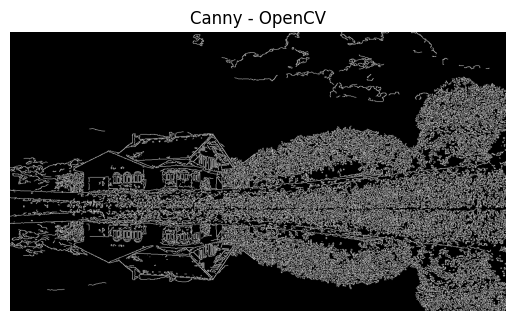

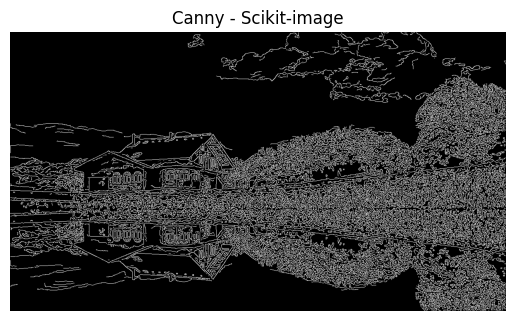

In [22]:
import cv2
import matplotlib.pyplot as plt

# Đọc ảnh
image = cv2.imread('lab03.jpg', cv2.IMREAD_GRAYSCALE)

# Áp dụng Canny
edges = cv2.Canny(image, threshold1=100, threshold2=200)

# Hiển thị
plt.imshow(edges, cmap='gray')
plt.title('Canny - OpenCV')
plt.axis('off')
plt.show()

from skimage import io, feature
import matplotlib.pyplot as plt

# Đọc ảnh
image = io.imread('lab03.jpg', as_gray=True)

# Áp dụng Canny
edges = feature.canny(image, sigma=1.0)

# Hiển thị
plt.imshow(edges, cmap='gray')
plt.title('Canny - Scikit-image')
plt.axis('off')
plt.show()

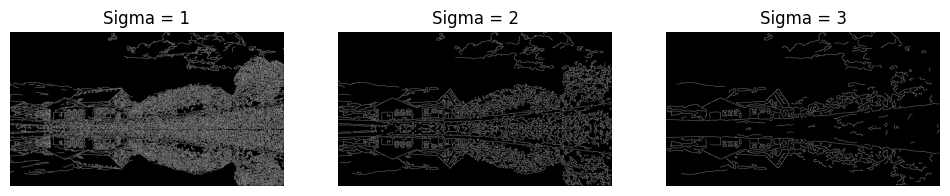

In [3]:
import matplotlib.pyplot as plt
from skimage import io, feature

image = io.imread('lab03.jpg', as_gray=True)

sigmas = [1, 2, 3]

plt.figure(figsize=(12,4))
for i, sigma in enumerate(sigmas):
    edges = feature.canny(image, sigma=sigma)
    
    plt.subplot(1,3,i+1)
    plt.imshow(edges, cmap='gray')
    plt.title(f'Sigma = {sigma}')
    plt.axis('off')

plt.show()

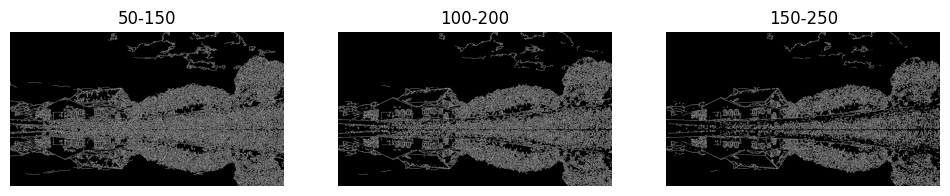

In [4]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('lab03.jpg', cv2.IMREAD_GRAYSCALE)

thresholds = [(50,150), (100,200), (150,250)]

plt.figure(figsize=(12,4))
for i, (low, high) in enumerate(thresholds):
    edges = cv2.Canny(image, low, high)
    
    plt.subplot(1,3,i+1)
    plt.imshow(edges, cmap='gray')
    plt.title(f'{low}-{high}')
    plt.axis('off')

plt.show()

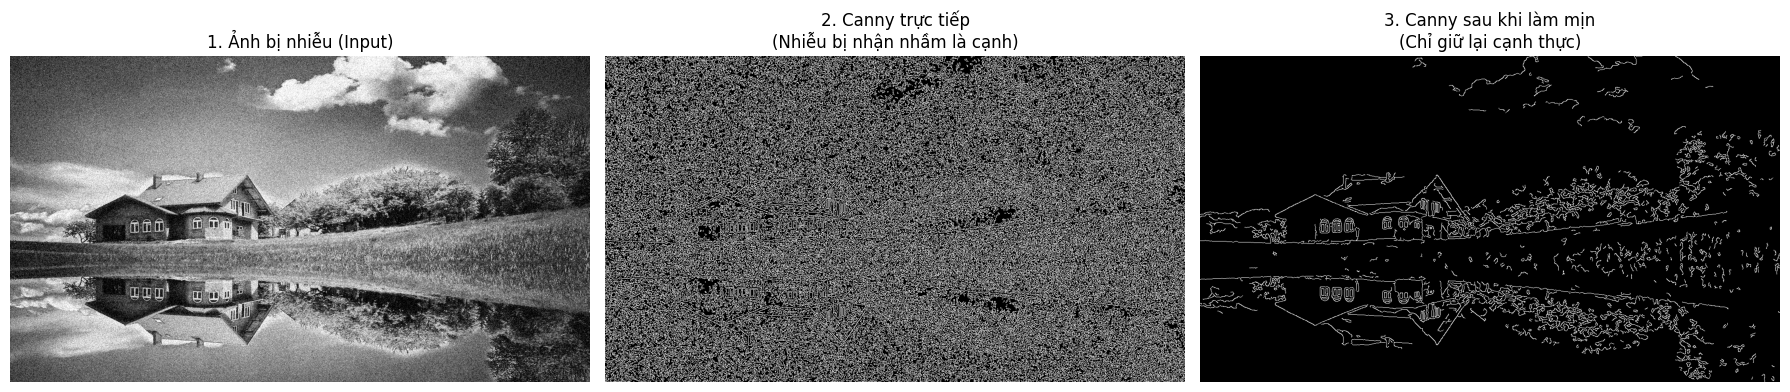

In [ ]:
# 1. Tạo nhiễu Gaussian
noise = np.random.normal(0, 25, image.shape)
noisy_image = np.clip(image + noise, 0, 255).astype('uint8')

# 2. Chạy Canny trực tiếp trên ảnh nhiễu (Không qua xử lý)
# Thấy rất nhiều "hạt bụi" trắng do Canny nhận nhầm nhiễu là cạnh
edges_direct = cv2.Canny(noisy_image, 100, 200)

# 3. Chạy Canny sau khi làm mịn (Xử lý chuẩn)
# Dùng GaussianBlur để loại bỏ các hạt nhiễu trước khi tìm cạnh
blurred = cv2.GaussianBlur(noisy_image, (5, 5), 1.5)
edges_filtered = cv2.Canny(blurred, 100, 200)

# --- HIỂN THỊ ĐỂ SO SÁNH ---
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(noisy_image, cmap='gray')
plt.title('1. Ảnh bị nhiễu (Input)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(edges_direct, cmap='gray')
plt.title('2. Canny trực tiếp\n(Nhiễu bị nhận nhầm là cạnh)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(edges_filtered, cmap='gray')
plt.title('3. Canny sau khi làm mịn\n(Chỉ giữ lại cạnh thực)')
plt.axis('off')

plt.tight_layout()
plt.show()

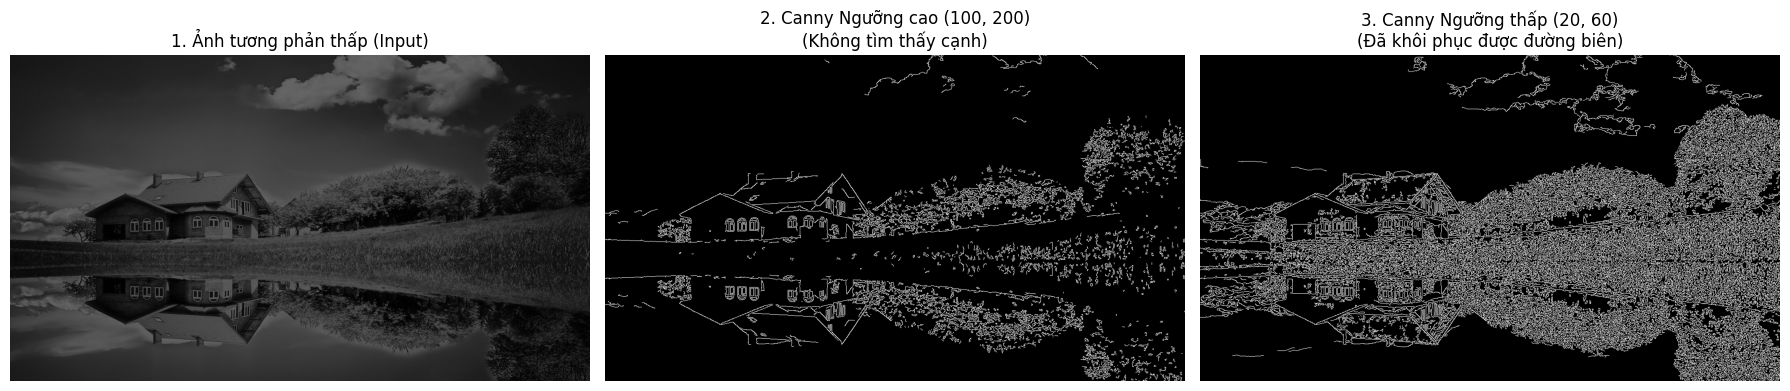

In [17]:
# 1. Tạo ảnh tương phản thấp (giảm độ sáng và độ lệch màu)
low_contrast = (image * 0.4).astype('uint8') 

# 2. Chạy Canny với ngưỡng mặc định (100, 200)
# Kết quả thường sẽ là một bức ảnh đen xì vì cạnh quá "yếu"
edges_default = cv2.Canny(low_contrast, 100, 200)

# 3. Chạy Canny với ngưỡng thấp (20, 50)
# Hạ ngưỡng xuống để "bắt" được các thay đổi cường độ nhỏ
edges_optimized = cv2.Canny(low_contrast, 20, 60)

# --- HIỂN THỊ SO SÁNH ---
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(low_contrast, cmap='gray', vmin=0, vmax=255)
plt.title('1. Ảnh tương phản thấp (Input)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(edges_default, cmap='gray')
plt.title('2. Canny Ngưỡng cao (100, 200)\n(Không tìm thấy cạnh)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(edges_optimized, cmap='gray')
plt.title('3. Canny Ngưỡng thấp (20, 60)\n(Đã khôi phục được đường biên)')
plt.axis('off')

plt.tight_layout()
plt.show()

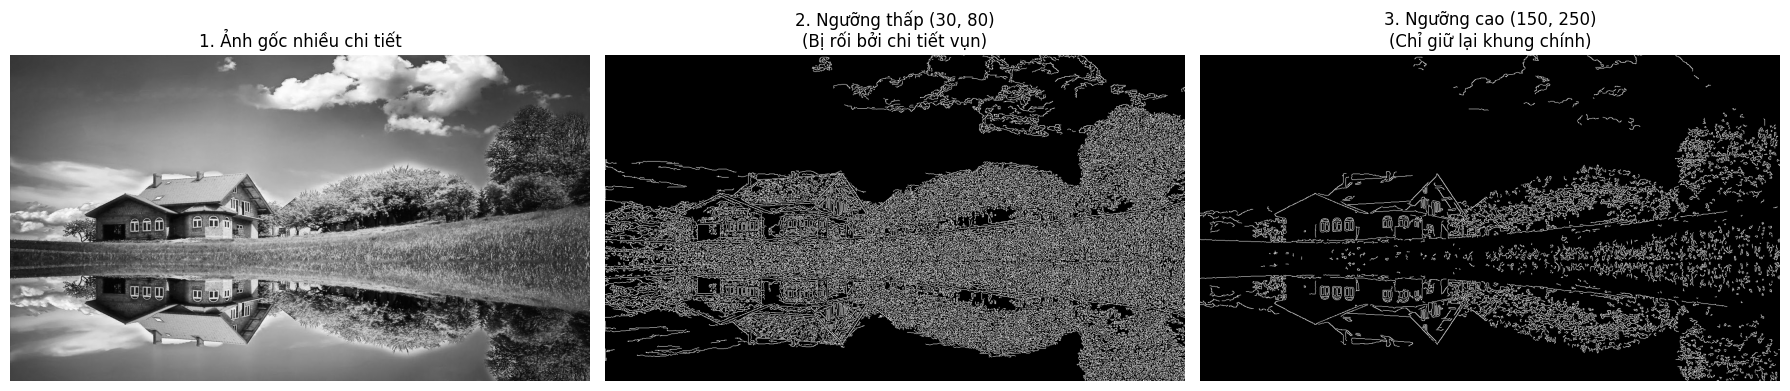

In [21]:
edges_low_thr = cv2.Canny(image, 30, 80)

# 3. Chạy Canny với ngưỡng cao + Làm mịn (Lọc chi tiết chính)
# Tăng ngưỡng cao giúp chỉ giữ lại các đường biên quan trọng nhất
blurred_detail = cv2.GaussianBlur(image, (3, 3), 0)
edges_high_thr = cv2.Canny(blurred_detail, 150, 250)

# --- HIỂN THỊ SO SÁNH ---
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('1. Ảnh gốc nhiều chi tiết')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(edges_low_thr, cmap='gray')
plt.title('2. Ngưỡng thấp (30, 80)\n(Bị rối bởi chi tiết vụn)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(edges_high_thr, cmap='gray')
plt.title('3. Ngưỡng cao (150, 250)\n(Chỉ giữ lại khung chính)')
plt.axis('off')

plt.tight_layout()
plt.show()

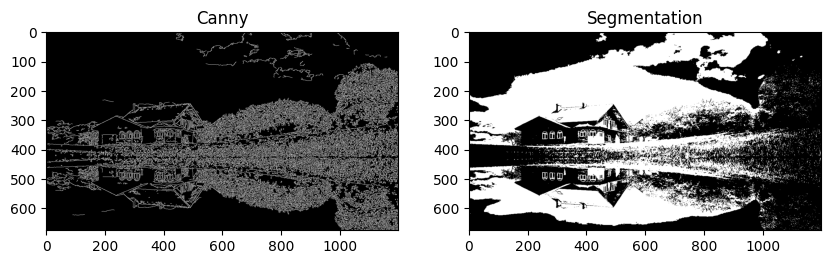

In [9]:
import cv2

# Canny
edges = cv2.Canny(image, 100, 200)

# Threshold segmentation
_, thresh = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(edges, cmap='gray')
plt.title('Canny')

plt.subplot(1,2,2)
plt.imshow(thresh, cmap='gray')
plt.title('Segmentation')

plt.show()

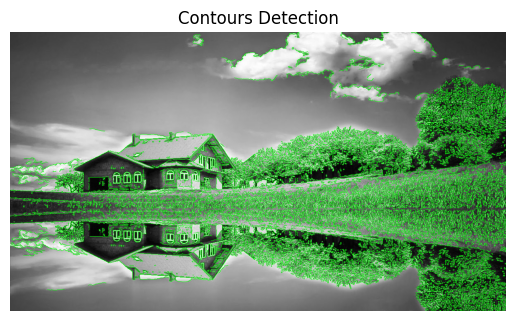

In [10]:
# Tìm contour từ ảnh cạnh
contours, _ = cv2.findContours(edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# Vẽ contour
image_color = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
cv2.drawContours(image_color, contours, -1, (0,255,0), 1)

plt.imshow(image_color)
plt.title('Contours Detection')
plt.axis('off')
plt.show()